In [1]:
import pandas as pd

df = pd.read_excel("April Payments.xlsx")

df.head()

,Date,Customer's Name,Agent's Name,Amount,Bank ( Llyods or Anna),Type,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,2026-04-01,Ketaki Mehta,Jack,50.0,Llyods,Initial,NaN,NaN,NaN,NaN,NaN
1,2026-04-03,Emmanuel Unekwuojo Ejiga,Hamza Khan,50.0,Llyods,Initial,NaN,NaN,NaN,NaN,NaN
2,2026-04-03,Robert Annan-Dugan,Sara,50.0,Llyods,Initial,NaN,NaN,NaN,NaN,NaN
3,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-04-03,MUHAMMED ABDUS SALIK,Sara,50.0,Llyods,Initial,NaN,NaN,NaN,NaN,NaN


In [2]:
# Remove unwanted columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Drop empty rows
df = df.dropna(how='all')

# Rename columns
df.columns = ['Date', 'Customer', 'Agent', 'Amount', 'Bank', 'Type']

# Convert types
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# Drop invalid rows
df = df.dropna(subset=['Date', 'Amount'])

# Filter April 2026
df = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 4)]

df.head()

,Date,Customer,Agent,Amount,Bank,Type
0,2026-04-01,Ketaki Mehta,Jack,50.0,Llyods,Initial
1,2026-04-03,Emmanuel Unekwuojo Ejiga,Hamza Khan,50.0,Llyods,Initial
2,2026-04-03,Robert Annan-Dugan,Sara,50.0,Llyods,Initial
4,2026-04-03,MUHAMMED ABDUS SALIK,Sara,50.0,Llyods,Initial
5,2026-04-03,Tare Leonard Ateboh,Sara,60.0,Llyods,Initial


In [3]:
income_types = [
    'Initial', 'Remaining', 'Flight Income', 'Total Amount',
    'Refund Income', 'Other Income', 'Visa Income'
]

expense_types = [
    'Insurance', 'Appointment Cost', 'Flight Cost', 'Refund',
    'Advertisement Cost', 'Official Expenses', 'Flight Purchase',
    'Ads Expense', 'Visa Fee'
]

df['Category'] = df['Type'].apply(
    lambda x: 'Income' if x in income_types else ('Expense' if x in expense_types else 'Other')
)

df.head()

,Date,Customer,Agent,Amount,Bank,Type,Category
0,2026-04-01,Ketaki Mehta,Jack,50.0,Llyods,Initial,Income
1,2026-04-03,Emmanuel Unekwuojo Ejiga,Hamza Khan,50.0,Llyods,Initial,Income
2,2026-04-03,Robert Annan-Dugan,Sara,50.0,Llyods,Initial,Income
4,2026-04-03,MUHAMMED ABDUS SALIK,Sara,50.0,Llyods,Initial,Income
5,2026-04-03,Tare Leonard Ateboh,Sara,60.0,Llyods,Initial,Income


In [4]:
total_income = df[df['Category'] == 'Income']['Amount'].sum()
total_expense = df[df['Category'] == 'Expense']['Amount'].sum()
profit = total_income - total_expense

print("Total Income:", total_income)
print("Total Expense:", total_expense)
print("Net Profit:", profit)

Total Income: 950.0
Total Expense: 228.56
Net Profit: 721.44


In [5]:
df['Category'].value_counts()

Category
Income     14
Expense     5
Other       2
Name: count, dtype: int64

In [6]:
df = df[(df['Date'].dt.year == 2026) & (df['Date'].dt.month == 4)]

In [7]:
df['Date'].dt.year.value_counts()

Date
2026    21
Name: count, dtype: int64

In [8]:
df = df[df['Date'].dt.month == 4]

In [9]:
df['Type'] = df['Type'].astype(str).str.strip()

In [10]:
income_types = [
    'Initial', 'Remaining', 'Flight Income', 'Total Amount',
    'Refund Income', 'Other Income', 'Visa Income'
]

expense_types = [
    'Insurance', 'Appointment Cost', 'Flight Cost', 'Refund',
    'Advertisement Cost', 'Official Expenses', 'Flight Purchase',
    'Ads Expense', 'Visa Fee'
]

df['Category'] = df['Type'].apply(
    lambda x: 'Income' if x in income_types else
    ('Expense' if x in expense_types else 'Other')
)

In [11]:
df[df['Category'] == 'Other']['Type'].unique()

<ArrowStringArray>
['Visa Cost']
Length: 1, dtype: str

In [12]:
total_income = df[df['Category'] == 'Income']['Amount'].sum()
total_expense = df[df['Category'] == 'Expense']['Amount'].sum()
net_profit = total_income - total_expense

print("Total Income:", total_income)
print("Total Expense:", total_expense)
print("Net Profit:", net_profit)
print(df['Category'].value_counts())

Total Income: 950.0
Total Expense: 228.56
Net Profit: 721.44
Category
Income     14
Expense     5
Other       2
Name: count, dtype: int64


In [13]:
import pandas as pd

df = pd.read_excel("April Payments.xlsx")

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df = df.dropna(how="all")
df.columns = ["Date", "Customer", "Agent", "Amount", "Bank", "Type"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Type"] = df["Type"].astype(str).str.strip()

df = df.dropna(subset=["Date", "Amount"])

# Include all April data, both 2025 and 2026
df = df[df["Date"].dt.month == 4]

income_types = [
    "Initial", "Remaining", "Flight Income", "Total Amount",
    "Refund Income", "Other Income", "Visa Income",
    "Refund in our Account", "Total Payment"
]

expense_types = [
    "Insurance", "Appointment Cost", "Flight Cost", "Refund",
    "Advertisement Cost", "Official Expenses", "Flight Purchase",
    "Ads Expense", "Visa Fee", "Visa Cost"
]

df["Category"] = df["Type"].apply(
    lambda x: "Income" if x in income_types else
    ("Expense" if x in expense_types else "Other")
)

total_income = df[df["Category"] == "Income"]["Amount"].sum()
total_expense = df[df["Category"] == "Expense"]["Amount"].sum()
net_profit = total_income - total_expense

print("Total Income:", round(total_income, 2))
print("Total Expense:", round(total_expense, 2))
print("Net Profit:", round(net_profit, 2))
print(df["Category"].value_counts())

Total Income: 7418.0
Total Expense: 3162.51
Net Profit: 4255.49
Category
Income     106
Expense     72
Name: count, dtype: int64


In [14]:
income_types = [
    "Initial", "Remaining", "Flight Income", "Total Amount",
    "Total Payment", "Visa Income", "Refund Income",
    "Refund in our Account", "Other Income"
]

expense_types = [
    "Insurance", "Appointment Cost", "Flight Cost", "Refund",
    "Advertisement Cost", "Official Expenses", "Flight Purchase",
    "Ads Expense", "Visa Fee", "Visa Cost"
]

df["Category"] = df["Type"].apply(
    lambda x: "Income" if x in income_types else
    ("Expense" if x in expense_types else "Other")
)

print(df.groupby("Type")["Amount"].sum().sort_values(ascending=False))
print("Income:", df[df["Category"]=="Income"]["Amount"].sum())
print("Expense:", df[df["Category"]=="Expense"]["Amount"].sum())
print("Profit:", df[df["Category"]=="Income"]["Amount"].sum() - df[df["Category"]=="Expense"]["Amount"].sum())

Type
Initial                  4680.00
Remaining                1375.00
Flight Cost               708.12
Appointment Cost          697.67
Flight Income             678.00
Ads Expense               500.00
Visa Fee                  404.20
Total Amount              385.00
Visa Cost                 360.64
Flight Purchase           179.94
Insurance                 168.94
Official Expenses         143.00
Total Payment             140.00
Visa Income                90.00
Refund Income              35.00
Refund in our Account      35.00
Name: Amount, dtype: float64
Income: 7418.0
Expense: 3162.51
Profit: 4255.49


In [15]:
print("Total Income:", total_income)
print("Total Expense:", total_expense)
print("Net Profit:", net_profit)

print("\nProfit Margin:", round((net_profit / total_income)*100, 2), "%")

Total Income: 7418.0
Total Expense: 3162.51
Net Profit: 4255.49

Profit Margin: 57.37 %


<Axes: title={'center': 'Income vs Expense'}, xlabel='Category'>

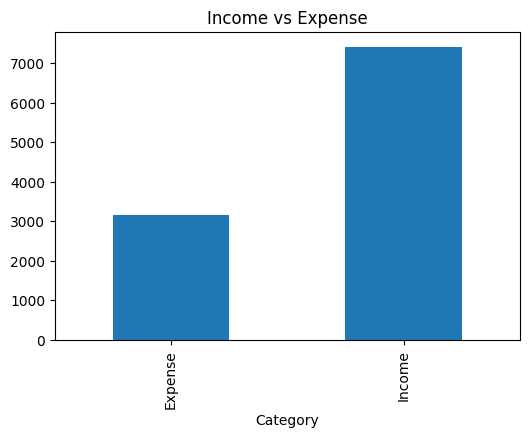

In [16]:
summary = df.groupby('Category')['Amount'].sum()

summary.plot(kind='bar', title="Income vs Expense", figsize=(6,4))

<Axes: xlabel='Type'>

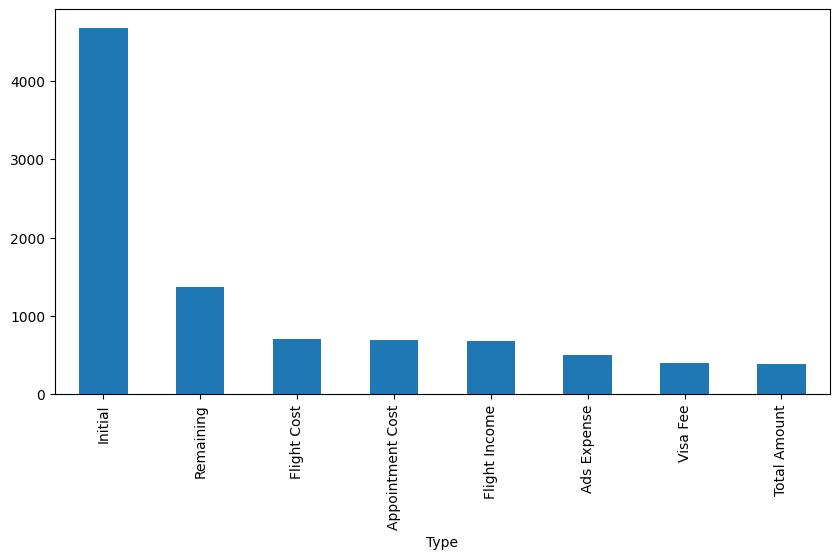

In [17]:
df.groupby('Type')['Amount'].sum().sort_values(ascending=False).head(8).plot(kind='bar', figsize=(10,5))

<Axes: xlabel='Agent'>

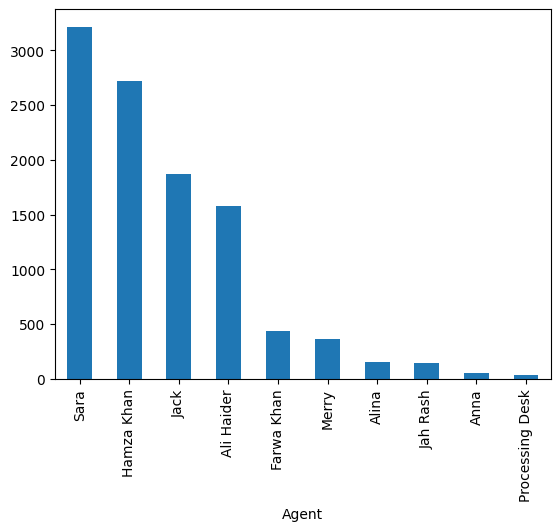

In [18]:
df.groupby('Agent')['Amount'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: title={'center': 'Daily Profit Trend'}, xlabel='Date'>

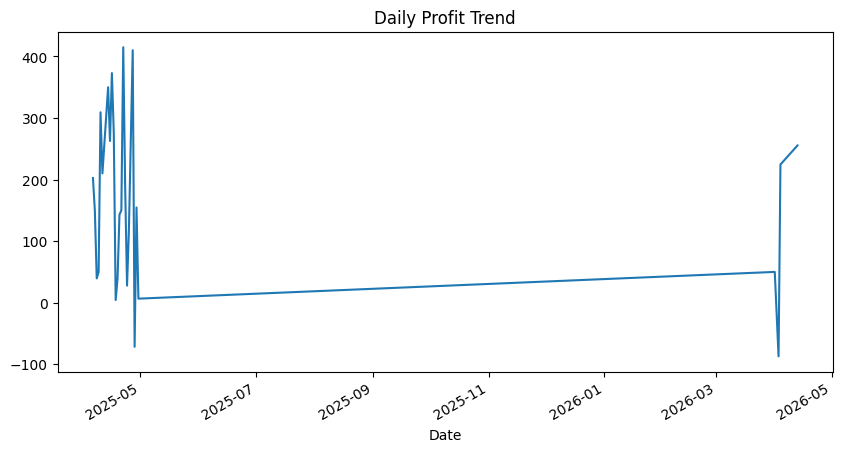

In [19]:
daily = df.groupby(['Date','Category'])['Amount'].sum().unstack().fillna(0)
daily['Profit'] = daily.get('Income',0) - daily.get('Expense',0)

daily['Profit'].plot(figsize=(10,5), title="Daily Profit Trend")